# **Mount Drive**

# **Yield Detrend**

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import detrend

fpath_yield = '<DATA_ROOT>/Yield/crops_us_yield_agg_irig.csv'
dfy = pd.read_csv(fpath_yield)
df_grouped = dfy.groupby(['state_name','county_name','prodn_practice_desc','commodity_desc'])

def detrend_yield(yield_series):
    detrended_yield = detrend(yield_series)
    return pd.Series(detrended_yield, index=yield_series.index)

dfy['detrended_yield'] = df_grouped['value_yield'].transform(detrend_yield)

fpath_fips = '<DATA_ROOT>/Yield/yield_fips_code.csv'
dffipsy = pd.read_csv(fpath_fips).rename(columns={' county_code':'county_code'})
df_new = dffipsy.copy()
formatted_numbers = [str(n).zfill(3) for n in df_new['county_code'].values]
df_new['county_code'] = formatted_numbers
formatted_numbers = [str(n).zfill(2) for n in df_new['state_fips_code'].values]
df_new['state_fips_code'] = formatted_numbers
df_new['FIPS'] = df_new['state_fips_code'] + df_new['county_code']
dffipsy = df_new
dffipsy = dffipsy.drop(columns=['state_fips_code' , 'county_code'])
dffipsy

dfy = pd.merge(dfy,dffipsy,on=['state_name', 'county_name'])
dfy.iloc[0:5]

In [ ]:
dfy.iloc[0:5]

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import detrend

df_grouped = dfy.groupby(['state_name','county_name','prodn_practice_desc','commodity_desc'])

# Define a detrending function using scipy's detrend
def detrend_yield(yield_series):
    detrended_yield = detrend(yield_series)
    return pd.Series(detrended_yield, index=yield_series.index)

# Apply the detrending function to the 'Yield' column of each group
dfy['detrended_yield'] = df_grouped['value_yield'].transform(detrend_yield)

# Display the result
dfy


In [ ]:
cond1 = dfy.commodity_desc == 'WHEAT'
cond2 = dfy.prodn_practice_desc == 'ALL PRODUCTION PRACTICES'
cond3 = dfy.state_name == 'WYOMING'
cond4 = dfy.county_name == 'WESTON'
dfy[cond1 & cond2 & cond3 & cond4][['year', 	'value_yield']].set_index('year').plot()

In [ ]:
dfy[cond1 & cond2 & cond3 & cond4][['year', 	'value_yield']].set_index('year').plot()
dfy[cond1 & cond2 & cond3 & cond4][['year', 	'detrended_yield']].set_index('year').plot()

# **Plot**

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

In [ ]:
states_dir = '<DATA_ROOT>/CONUS_States/'
gdf_states = gpd.read_file(states_dir)
gdf_states

In [ ]:
shp_counties = '<DATA_ROOT>/SVI/Counties/'
counties = gpd.read_file(shp_counties)
# formatted_numbers = [int(n) for n in counties['FIPS'].values]
# counties['FIPS'] = formatted_numbers

In [ ]:
# fpath1 = '<DATA_ROOT>/WeatherIndex/Temp_Tercile_11nov.csv'
# dft = pd.read_csv(fpath1)
# dft = dft.rename(columns={'Year':'year'})
# dft.iloc[0:5,:]

fpath2 = '<DATA_ROOT>/WeatherIndex/Drought_Map.csv'
dfd = pd.read_csv(fpath2)
dfd = dfd.rename(columns={'Year':'year', 'STATE':'State', 'COUNTY':'County'})
fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
dfd = pd.merge(dfd,df_fips_obj,on=['OBJECTID'])
dfd

In [ ]:
drought_indices = ['PDSI', 'SPEI3', 'SPEI6', 'SPEI9', 'SPEI12', 'SPI3', 'SPI6', 'SPI9', 'SPI12']
for idx in drought_indices:
  dfd.loc[dfd[idx] == 0,idx] = 1
dfd

In [ ]:
cond_irig = dfy['prodn_practice_desc'] == 'ALL PRODUCTION PRACTICES'
dfy = dfy[cond_irig]
dfy['FIPS'] = dfy['FIPS'].astype(str)

formatted_numbers = [str(n).zfill(5) for n in dfd['FIPS'].values]
dfd['FIPS'] = formatted_numbers

df_merge = pd.merge(dfy,dfd,on=['FIPS','year'])
# df_merge = df_merge[['commodity_desc', 'FIPS', 'value_yield','detrended_yield',
#             'PDSI', 'SPEI3', 'SPEI6', 'SPEI9', 'SPEI12', 'SPI3',
#             'SPI6', 'SPI9', 'SPI12']]
df_merge = df_merge[['commodity_desc', 'FIPS', 'detrended_yield','SPEI9','year']]

grp_cols = ['FIPS' ,'commodity_desc','SPEI9']
dfy_grp = df_merge.groupby(grp_cols).detrended_yield.mean().reset_index()
dfy_grp

In [ ]:
df_merge_new = df_merge[['FIPS', 'commodity_desc', 'year', 'detrended_yield']]
df_merge_new = df_merge_new.sort_values(['FIPS', 'commodity_desc', 'year'])

def cal_change(group):
    return group.diff()

df_merge_new['diff_yield'] = df_merge_new.groupby(['FIPS', 'commodity_desc'])['detrended_yield'].transform(cal_change)
df_merge_new


In [ ]:
df_merge_new = df_merge_new.dropna()
df_ylddiff_sum = df_merge_new[df_merge_new.diff_yield<0].groupby(['year','FIPS']).diff_yield.sum()
df_ylddiff_sum = df_ylddiff_sum.reset_index()
df_ylddiff_count = df_ylddiff_sum.groupby('FIPS').count()
cnt_ylddiff_count = pd.merge(counties,df_ylddiff_count,on=['FIPS'])
print(cnt_ylddiff_count.diff_yield.max() , cnt_ylddiff_count.diff_yield.min())
cnt_ylddiff_count

In [ ]:
cnt_ylddiff_count[['FIPS','diff_yield']]

In [ ]:
# cond_drought = dfy_grp.SPEI9 == 1
# cnt_yld_dr = pd.merge(counties,dfy_grp[cond_drought],on=['FIPS']).set_index(['FIPS','commodity_desc'])

# cond_drought = dfy_grp.SPEI9 == -1
# cnt_yld_no_dr = pd.merge(counties,dfy_grp[cond_drought],on=['FIPS']).set_index(['FIPS','commodity_desc'])

# diff_dr_nodr = cnt_yld_dr.detrended_yield - cnt_yld_no_dr.detrended_yield
# diff_dr_nodr = diff_dr_nodr.reset_index().dropna().rename(columns={'detrended_yield':'diff_dr_nodr'})

# cnt_yld_no_dr = cnt_yld_no_dr.reset_index()[['FIPS','commodity_desc','detrended_yield']]
# rate_dr_nodr = pd.merge(diff_dr_nodr,cnt_yld_no_dr,on=['FIPS','commodity_desc'])
# rate_dr_nodr['per_change'] = rate_dr_nodr.diff_dr_nodr/rate_dr_nodr.detrended_yield.abs() * 100
# cnt_rate_dr_nodr = rate_dr_nodr.groupby(['FIPS']).mean().reset_index()
# cnt_rate_dr_nodr = pd.merge(counties,cnt_rate_dr_nodr[['FIPS','per_change']],on=['FIPS'])
# cnt_rate_dr_nodr


In [ ]:
cnt_ylddiff_count[['FIPS','diff_yield']]

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
# colors = ['#8c510a','#bf812d','#dfc27d','#f6e8c3','#f5f5f5','#f5f5f5','#c7eae5','#80cdc1','#35978f','#01665e']
# colors = ['#ffffb2','#fed976','#feb24c','#fd8d3c','#fc4e2a','#e31a1c','#b10026']
colors = ['#ffffcc','#ffeda0','#fed976','#feb24c','#fd8d3c','#fc4e2a','#e31a1c','#b10026']

colors = colors
cmap = ListedColormap(colors)
range_values = cnt_ylddiff_count.quantile(list(np.arange(0,9) * 12.5 / 100))
range_values = list(range_values.diff_yield)
norm = BoundaryNorm(range_values, len(colors))
cnt_ylddiff_count
fig , ax = plt.subplots(1,1,dpi=1200)
counties.plot(ax=ax, color='none', edgecolor='black', alpha=0.2,linewidth=0.2)
cnt_ylddiff_count.plot(column='diff_yield',cmap=cmap,
                      norm=norm,legend=False,
                      linewidth=0.1,ax=ax,edgecolor='black')
# cnt_rate_dr_nodr.plot(column='per_change',cmap=cmap,vmin=-200,vmax=200,
#                       norm=norm,legend=False,
#                       linewidth=0.1,ax=ax,edgecolor='black')
gdf_states.plot(ax=ax, color='none', edgecolor='black', linewidth=0.4)

ax.set_xticks([])
ax.set_yticks([])

cax = fig.add_axes([0.8, 0.25, 0.02, 0.2])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=6)

out_path = '<DATA_ROOT>/Final_Exports/20231119-Section1/'
plt.savefig(out_path + 'Map_Counties_Yield_Decrease_count' + '.png' , dpi=1200)
plt.close()


In [ ]:
diff_yield = pd.read_csv('/content/diff_yield.csv')
failshare = pd.read_csv('/content/failshare.csv')

df = pd.merge(failshare,diff_yield,on=['FIPS'])[['FIPS','fail_share','diff_yield']]#.set_index('FIPS')
# df = df[df.fail_share>1]
# df = df[df.diff_yield>1]

correlation = df['fail_share'].corr(df['diff_yield'])
print(correlation)

df = df.groupby(['fail_share','diff_yield']).count().reset_index()
df['FIPS'] = df['FIPS'] * 4
# df = df[df.fail_share>4]

# df['fail_share'].plot()
# df['diff_yield'].plot()
df.plot(x='fail_share', y='diff_yield', kind='scatter' , s='FIPS')

In [ ]:
df

# old

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
colors = ['#543005','#8c510a','#bf812d','#dfc27d','#f6e8c3','#c7eae5','#80cdc1','#35978f','#01665e','#003c30']
cmap = ListedColormap(colors)
range_values = list(np.arange(-10,11,2)/10)
norm = BoundaryNorm(range_values, len(colors))


fig , axes = plt.subplots(1,2,figsize=(15,30))
cond_crop = dfy_grp.commodity_desc == 'WHEAT'

cond_drought = dfy_grp.SPEI9 == 1
counties_yld = pd.merge(counties,dfy_grp[cond_crop & cond_drought],on=['FIPS'])
# counties.plot(ax=axes[0], color='none', edgecolor='black', alpha=0.2,linewidth=0.2)
counties_yld.plot(column='detrended_yield',ax=axes[0],cmap=cmap, norm=norm)

cond_drought = dfy_grp.SPEI9 == -1
counties_yld = pd.merge(counties,dfy_grp[cond_crop & cond_drought],on=['FIPS'])
# counties.plot(ax=axes[1], color='none', edgecolor='black', alpha=0.2,linewidth=0.2)
counties_yld.plot(column='detrended_yield',ax=axes[1],cmap=cmap, norm=norm)

cax = fig.add_axes([0.35, 0, 0.3, 0.02])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=6)

In [ ]:
# from matplotlib.colors import ListedColormap, BoundaryNorm
# colors = ['#543005','#8c510a','#bf812d','#dfc27d','#f6e8c3','#c7eae5','#80cdc1','#35978f','#01665e','#003c30']
# cmap = ListedColormap(colors)
# range_values = list(np.arange(-10,11,2)/10)
# norm = BoundaryNorm(range_values, len(colors))


# fig , axes = plt.subplots(1,2,figsize=(15,30))
cond_crop = dfy_grp.commodity_desc == 'HAY'

cond_drought = dfy_grp.SPEI9 == 1
counties_yld_drought = pd.merge(counties,dfy_grp[cond_crop & cond_drought],on=['FIPS'])

cond_drought = dfy_grp.SPEI9 == -1
counties_yld_no_drought = pd.merge(counties,dfy_grp[cond_crop & cond_drought],on=['FIPS'])



# # counties.plot(ax=axes[0], color='none', edgecolor='black', alpha=0.2,linewidth=0.2)
# counties_yld.plot(column='detrended_yield',ax=axes[0],cmap=cmap, norm=norm)


# # counties.plot(ax=axes[1], color='none', edgecolor='black', alpha=0.2,linewidth=0.2)
# counties_yld.plot(column='detrended_yield',ax=axes[1],cmap=cmap, norm=norm)

# cax = fig.add_axes([0.35, 0, 0.3, 0.02])
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
# cbar.ax.tick_params(labelsize=6)

<Axes: >

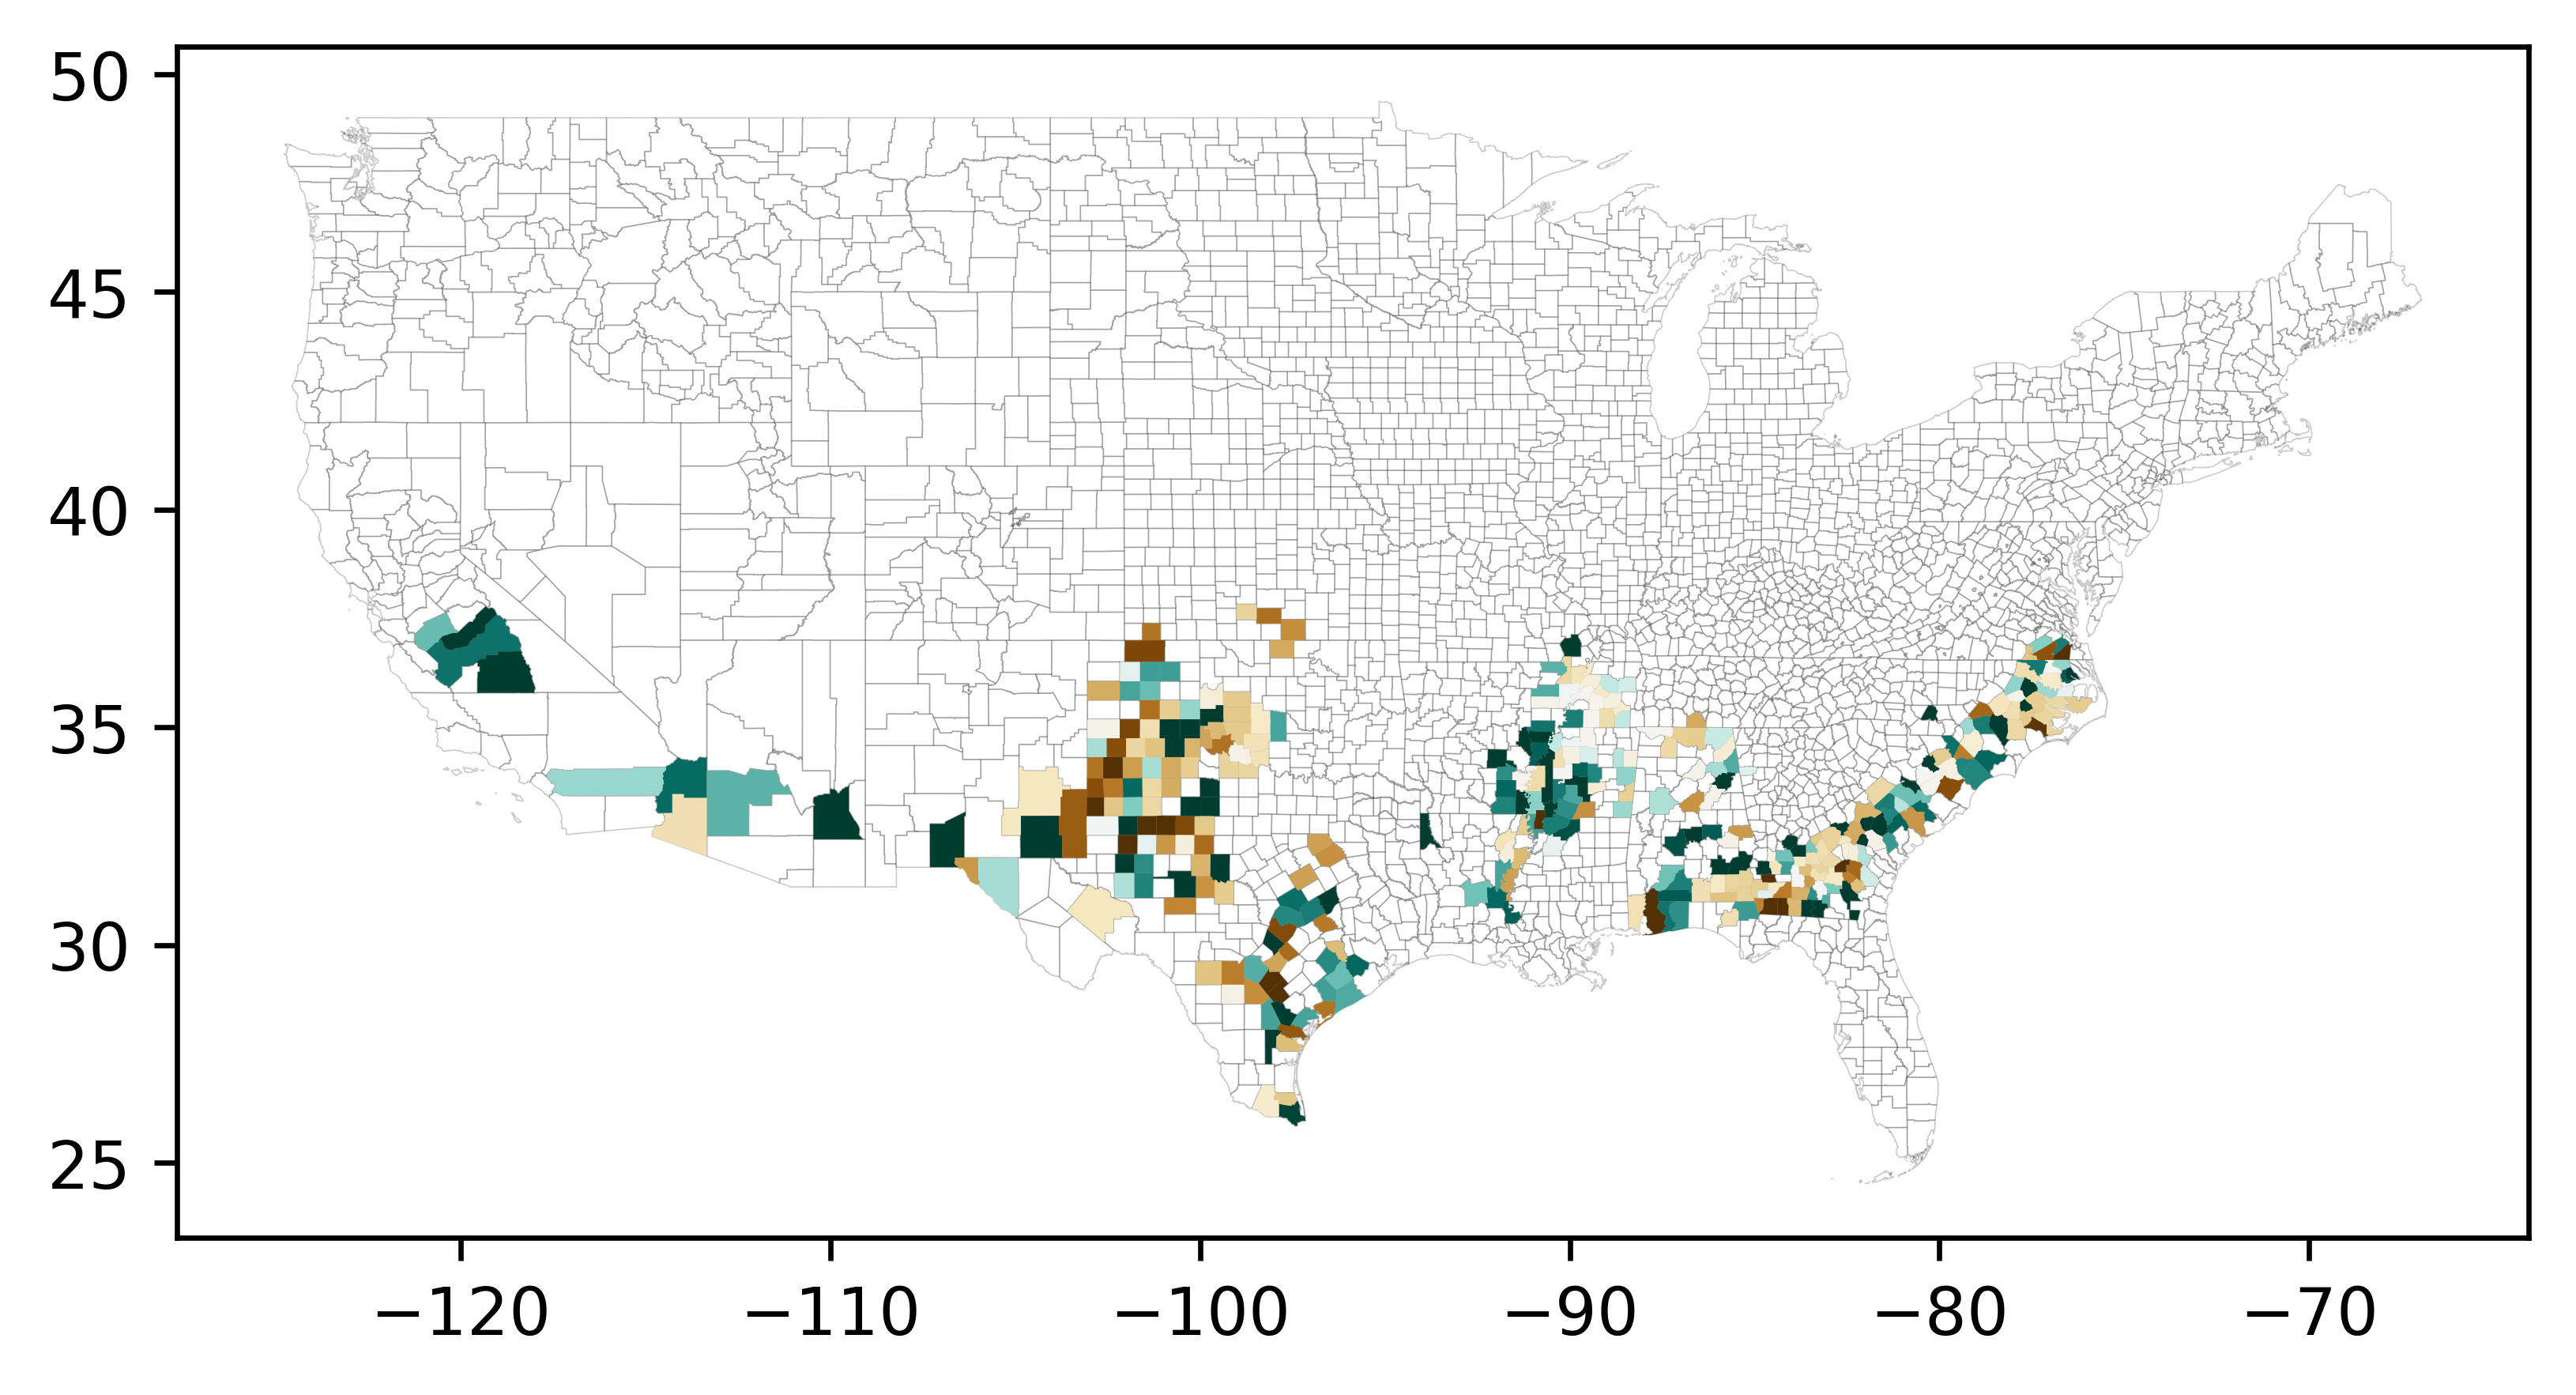

In [ ]:
fig , ax = plt.subplots(1,1,dpi=600)
rate_dr_nodr = counties_yld_drought.set_index('FIPS').detrended_yield - counties_yld_no_drought.set_index('FIPS').detrended_yield
rate_dr_nodr = rate_dr_nodr / counties_yld_no_drought.set_index('FIPS').detrended_yield.abs() * 100
counties_rate_dr_nodr = pd.merge(counties,rate_dr_nodr.dropna().reset_index(),on=['FIPS'])
counties.plot(ax=ax,color='none', edgecolor='black', alpha=0.2,linewidth=0.2)
counties_rate_dr_nodr.plot(ax=ax,column='detrended_yield',vmin=-200,vmax=200,cmap='BrBG')

In [ ]:
counties_rate_dr_nodr.detrended_yield.max()

2012.0149253716106

In [ ]:
counties_rate_dr_nodr.detrended_yield.min()

-195.9006186548944

In [ ]:
counties_rate_dr_nodr[['FIPS','detrended_yield']]

,FIPS,detrended_yield
0,04015,-0.999359
1,05001,-0.939038
2,05017,-1.688312
3,05021,0.144519
4,05029,-0.514484
...,...,...
1330,55141,0.155611
1331,56005,1.873766
1332,56015,-0.959230
1333,56021,0.436473


from matplotlib import pyplot as plt
_df_0['detrended_yield'].plot(kind='hist', bins=20, title='detrended_yield')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['detrended_yield'].plot(kind='line', figsize=(8, 4), title='detrended_yield')
plt.gca().spines[['top', 'right']].set_visible(False)